# JAX 101 Assignment: High-Performance Numerical Computing

**Audience:** Mathematics students (Numerical Analysis / Scientific ML)

| Part | Topic | Core APIs |
|------|-------|-----------|
| 1 | JIT compilation | `jit`, `lax.while_loop` |
| 2 | Vectorisation & explicit randomness | `vmap`, `random.split` |
| 3 | Automatic vs. numerical differentiation | `grad`, `value_and_grad` |
| 4 | PyTree state management | `jax.tree.map` |
| 5 | Capstone: PINN | all of the above + `lax.fori_loop` |

**Submission:** Return this notebook with all cells executed and all plots visible.

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
from jax import jit, vmap, grad, value_and_grad
from jax import lax, random
import timeit
import time
import matplotlib.pyplot as plt

jax.config.update('jax_enable_x64', True)
print('JAX version:', jax.__version__)
print('Backend    :', jax.default_backend())

JAX version: 0.7.2
Backend    : cpu


---
## Part 1 — The Power of Compilation: `jit` vs. NumPy

Python dispatches every NumPy operation through the interpreter, paying per-call overhead. `@jit` traces a function once, compiles it to an XLA binary, and runs that binary on all subsequent calls.

**Key constraint.** JIT traces with *abstract* values (shapes and dtypes only). A Python `while` loop whose iteration count depends on a runtime value cannot be compiled — JAX raises a `ConcretizationTypeError`. The correct replacement is `jax.lax.while_loop(cond_fun, body_fun, init_val)`, which encodes the loop as a primitive the compiler understands.

**Math — Bisection method.** Given $f:[a,b]\to\mathbb{R}$ continuous with $f(a)\cdot f(b)<0$, iteratively halve the interval: compute $m=(a+b)/2$, then replace whichever endpoint shares the sign of $f(m)$. Stop when $|b-a|<\varepsilon$.

In [2]:
# Setup — test function and bracket (given)
def f_scalar(x):
    """f(x) = x^3 - x - 2.  Works with both Python floats and jnp scalars."""
    return x**3 - x - 2

A, B, TOL = 1.0, 2.0, 1e-8
print(f'f({A}) = {f_scalar(A):.4f},  f({B}) = {f_scalar(B):.4f}')

f(1.0) = -2.0000,  f(2.0) = 4.0000


### Task 1 — NumPy bisection

Implement `bisection_np` using a standard Python `while` loop and plain Python/NumPy arithmetic.

In [3]:
def bisection_np(f, a, b, tol=1e-8):
    """
    Input : f — callable (float -> float)
            a, b — bracket endpoints (floats, f(a)*f(b) < 0)
            tol  — convergence tolerance
    Output: approximate root (float)
    """
    while np.abs(b - a) >= tol:
        m = (a + b) / 2.0
        a = np.where(f(a) * f(m) < 0, a, m)
        b = np.where(f(a) * f(m) < 0, m, b)
    return (a + b) / 2.0



In [4]:
# Test
root_np = bisection_np(f_scalar, A, B, TOL)
print(f'root = {root_np:.10f},  |f(root)| = {abs(f_scalar(root_np)):.2e}')
assert abs(f_scalar(root_np)) < 1e-7

root = 1.5213797055,  |f(root)| = 7.64e-09


### Tasks 2 & 3 — JAX bisection

**Task 3 (do this first).** The cell below intentionally uses a Python `while` loop on a traced JAX value. Run it, read the error, and write a short explanation in the answer cell below.

In [5]:
# Expected to FAIL — do not modify this cell
@jit
def bisection_jax_broken(a, b):
    while jnp.abs(b - a) >= TOL:          # Python while on a traced value
        m = (a + b) / 2.0
        a = jnp.where(f_scalar(a) * f_scalar(m) < 0, a, m)
        b = jnp.where(f_scalar(a) * f_scalar(m) < 0, m, b)
    return (a + b) / 2.0

try:
    bisection_jax_broken(jnp.float64(A), jnp.float64(B))
except Exception as e:
    print(type(e).__name__, ':', e)

TracerBoolConversionError : Attempted boolean conversion of traced array with shape bool[].
The error occurred while tracing the function bisection_jax_broken at /tmp/ipykernel_6756/3935172514.py:2 for jit. This concrete value was not available in Python because it depends on the values of the arguments a and b.
See https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerBoolConversionError


**Answer (Task 3):** \
The jit compiler read this function and found out that there is one thing can't be jitted. I think it is mainly because the number of iterations doing while loop depends on the input a,b and the function to be solve. Jit can't compile function that don't have exact amount of workflows

**Task 2.** Implement `bisection_jax` using `jax.lax.while_loop`. The loop state must be a tuple of JAX arrays that both `cond_fun` and `body_fun` accept and return.

In [6]:
@jit
def bisection_jax(a, b, tol=1e-8):
    """
    Input : a, b — jnp.float64 scalars (bracket endpoints)
            tol  — convergence tolerance (Python float, treated as static)
    Output: approximate root as jnp.float64 scalar
    """

    def cond_fun(state):
        a, b = state
        return (b - a) / 2 > tol                   # keep looping until converged

    def body_fun(state):
        a, b = state
        mid = (a + b) / 2.0
        # np.where instead of if/else — state must stay JAX arrays
        a = jnp.where(f_scalar(a) * f_scalar(mid) <= 0, a, mid)
        b = jnp.where(f_scalar(a) * f_scalar(mid) <= 0, mid, b)
        return (a, b)

    a, b = jax.lax.while_loop(cond_fun, body_fun, (a, b))  # state = tuple of arrays
    return (a + b) / 2.0

In [7]:
# Warm-up (excludes compilation from benchmark)
_ = bisection_jax(jnp.float64(A), jnp.float64(B)).block_until_ready()

root_jax = bisection_jax(jnp.float64(A), jnp.float64(B))
print(f'root = {float(root_jax):.10f},  |f(root)| = {abs(float(f_scalar(root_jax))):.2e}')
assert abs(float(f_scalar(root_jax))) < 1e-7

root = 1.5213797018,  |f(root)| = 2.98e-08


### Task 4 — Benchmark

Time 1 000 repeated calls of each version. Call `.block_until_ready()` on the JAX version to ensure the device computation finishes before the timer stops. Report per-call time and speedup ratio, and explain the source of the speedup.

In [8]:
N_REPS = 1000
a_j, b_j = jnp.float64(A), jnp.float64(B)

t_np  = timeit.timeit(lambda: bisection_np(f_scalar, A, B), number=N_REPS) / N_REPS
t_jax = timeit.timeit(lambda: bisection_jax(a_j, b_j).block_until_ready(), number=N_REPS) / N_REPS

print(f'NumPy : {t_np*1e6:.2f} µs/call')
print(f'JAX   : {t_jax*1e6:.2f} µs/call')
print(f'Speedup: {t_np/t_jax:.1f}x')

# Written answer:
# Q: Where does the speedup come from?  Why must we call block_until_ready()?
# A: 1. The speed up came from jit compile of this function
# By assigning the exact loop iteration to converge, the jax can compile the whole program
# 2. If not the time duration measured only has the dispatchtime, without computation time spend

NumPy : 326.83 µs/call
JAX   : 6.98 µs/call
Speedup: 46.8x


---
## Part 2 — Vectorisation without Tears: `vmap` vs. Loops

`jax.vmap` transforms a single-instance function into a batched one without any explicit loop. Unlike a Python `for` loop, `vmap` fuses the batch axis into the computation graph before compilation.

### Randomness in JAX — a critical difference from NumPy

NumPy has a hidden global random state. JAX has **no global state**: every random call requires an explicit **PRNG key**.

> **Golden rule: never reuse a key. Always split before use.**

```
key  = jax.random.key(seed)          # create from integer seed
k1, k2 = jax.random.split(key)       # two independent sub-keys
keys = jax.random.split(key, N)      # N independent sub-keys, shape (N,)
z    = jax.random.normal(key, shape) # sample N(0,1); key is consumed
```

Passing the **same** key to $N$ batched calls silently produces $N$ **identical** sequences — a common silent bug.

### Math — Geometric Brownian Motion

Euler–Maruyama discretisation of $dX_t = \mu X_t\,dt + \sigma X_t\,dW_t$ with step $\Delta t = T/N$:

$$X_{t+\Delta t} = X_t + \mu X_t \Delta t + \sigma X_t \sqrt{\Delta t}\; Z_t, \qquad Z_t\sim\mathcal{N}(0,1)$$

Exact expected terminal value: $\mathbb{E}[X_T] = X_0 e^{\mu T}$.

In [9]:
# Setup (given)
MU, SIGMA, X0 = 0.05, 0.20, 100.0
T_END, N_STEPS, N_PATHS = 1.0, 252, 10_000
MASTER_KEY = random.key(42)

### Task 1 — Single-path simulation

Implement `sim_path`. All randomness must come from the `key` argument — do **not** create or split keys inside the function.

In [10]:
def sim_path(key, x0, mu=MU, sigma=SIGMA, T=T_END, N=N_STEPS):
    """
    Input : key   — JAX PRNG key (sole source of randomness)
            x0    — scalar initial value
            mu, sigma, T, N — GBM parameters
    Output: jnp.array of shape (N+1,) — full trajectory from X_0 to X_T
    """
    x = x0
    x_list = [x0]
    delta_t = T_END/N_STEPS
    for _ in range(N_STEPS):
        x = x + mu*x*delta_t + sigma*x*jnp.sqrt(delta_t)*random.normal(key)
        x_list.append(x)

    return jnp.array(x_list)

In [11]:
# Test
path = sim_path(random.key(0), X0)
print('shape:', path.shape)        # expected (253,)
assert path.shape == (N_STEPS + 1,)
assert float(path[0]) == X0

shape: (253,)


### Task 2 — Key splitting and the reuse bug

Generate `N_PATHS` independent keys from `MASTER_KEY` using `jax.random.split`. Then run the demonstration cell below and explain the key-reuse bug in writing.

In [12]:
# Generate batch_keys of shape (N_PATHS,)
batch_keys = jax.random.split(MASTER_KEY, N_PATHS)

In [13]:
# Test shape
assert batch_keys.shape == (N_PATHS,)

# Demonstrate the silent reuse bug
k = random.key(0)
z1 = random.normal(k, shape=(4,))
z2 = random.normal(k, shape=(4,))   # same key → identical output!
print('Same key reused — z1 == z2?', jnp.allclose(z1, z2))

# Written answer:
# Q: If you passed MASTER_KEY to every sim_path call instead of batch_keys,
#    what would go wrong in the simulation results?
# A: You will get exactly the same result in each time when you simulate

Same key reused — z1 == z2? True


### Task 3 — Loop simulation (slow baseline)

In [14]:
# Use a Python for-loop over batch_keys to collect terminal values X_T
def sim_np(x0, mu=MU, sigma=SIGMA, T=T_END, N=N_STEPS, n_paths=N_PATHS, seed=0):
    rng = np.random.default_rng(seed)
    delta_t = T / N

    x = np.full(n_paths, x0)                                 # (N_PATHS,)

    for _ in range(N):
        Z = rng.standard_normal(n_paths)                     # (N_PATHS,)
        x = x + mu*x*delta_t + sigma*x*np.sqrt(delta_t)*Z

    return x                                                  # (N_PATHS,)

terminal_loop = sim_np(X0)
# terminal_loop = ...   shape (N_PATHS,)

In [15]:
assert terminal_loop.shape == (N_PATHS,)
print(f'Loop mean: {float(jnp.mean(terminal_loop)):.4f}')

Loop mean: 105.2185


### Task 4 — Vectorised simulation with `vmap`

Vectorise `sim_path` over `key` only. The scalar arguments `mu, sigma, T, N` are shared across paths and must **not** be batched (`in_axes=None` for those positions).

In [16]:
def sim_paths(key, x0, mu=MU, sigma=SIGMA, T=T_END, N=N_STEPS):
    delta_t = T / N
    step_keys = random.split(key, N)

    def step(x, k):
        x_next = x + mu*x*delta_t + sigma*x*jnp.sqrt(delta_t)*random.normal(k)
        return x_next, x_next              # (carry, output) ← record every step

    x_T, path = jax.lax.scan(step, x0, step_keys)
    full_path = jnp.concatenate([jnp.array([x0]), path])   # prepend x0

    return x_T, full_path

# vmap over batch_keys
sim_paths_vmap = vmap(sim_paths, in_axes=(0, None))
terminal_vmap, all_paths = sim_paths_vmap(batch_keys, X0)

In [17]:
assert all_paths.shape == (N_PATHS, N_STEPS + 1)

exact_mean = float(X0 * np.exp(MU * T_END))
mc_mean    = float(jnp.mean(terminal_vmap))
print(f'Monte Carlo E[X_T] : {mc_mean:.4f}')
print(f'Exact       E[X_T] : {exact_mean:.4f}')
print(f'Relative error     : {abs(mc_mean - exact_mean)/exact_mean:.4%}')
assert abs(mc_mean - exact_mean) / exact_mean < 0.05

Monte Carlo E[X_T] : 105.1325
Exact       E[X_T] : 105.1271
Relative error     : 0.0051%


### Task 5 — Benchmark and analysis

Loop : 510.714 s
vmap : 0.560 s
Speedup: 912.5x


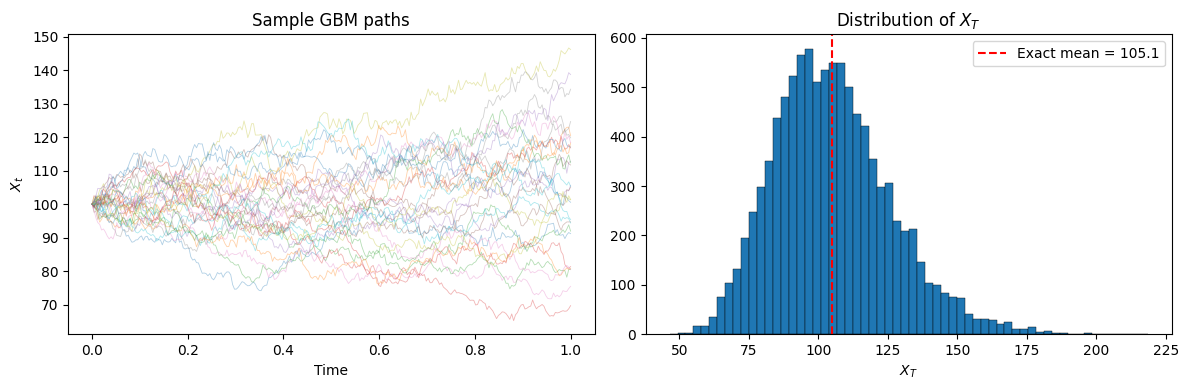

In [20]:
_ = sim_paths_vmap(batch_keys, X0)[0].block_until_ready()   # warm-up

t_loop = timeit.timeit(lambda: [sim_path(k, X0) for k in batch_keys], number=3) / 3
t_vmap = timeit.timeit(
    lambda: sim_paths_vmap(batch_keys, X0)[0].block_until_ready(), number=10) / 10

print(f'Loop : {t_loop:.3f} s')
print(f'vmap : {t_vmap:.3f} s')
print(f'Speedup: {t_loop/t_vmap:.1f}x')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
t_grid = np.linspace(0, T_END, N_STEPS + 1)
for i in range(30):
    axes[0].plot(t_grid, all_paths[i], alpha=0.35, linewidth=0.6)
axes[0].set(title='Sample GBM paths', xlabel='Time', ylabel='$X_t$')
axes[1].hist(np.array(terminal_vmap), bins=60, edgecolor='k', linewidth=0.3)
axes[1].axvline(exact_mean, color='red', linestyle='--', label=f'Exact mean = {exact_mean:.1f}')
axes[1].set(title='Distribution of $X_T$', xlabel='$X_T$')
axes[1].legend()
plt.tight_layout(); plt.show()

# Written answer:
# Q: Explain how in_axes controls which arguments vmap batches over.
# A: vmap(sim_paths, in_axes=(0, None))
# (0, None) decide the axis to do parallel for variable (keys, X0)
# 0 for keys means doing parallel in different key in keys

---
## Part 3 — Gradient-Based Optimisation: `grad`

Gradient descent updates $\mathbf{x}_{k+1} = \mathbf{x}_k - \alpha\nabla\mathcal{L}(\mathbf{x}_k)$. How accurately $\nabla\mathcal{L}$ is computed determines convergence.

**Finite-difference (FD)** central difference:
$$\frac{\partial\mathcal{L}}{\partial x_j}\approx\frac{\mathcal{L}(\mathbf{x}+h\mathbf{e}_j)-\mathcal{L}(\mathbf{x}-h\mathbf{e}_j)}{2h}$$
Cost: $2d$ evaluations. Accuracy: limited by truncation ($h$ too large) and cancellation ($h$ too small).

**Automatic Differentiation (AD)** via `jax.grad`: exact gradient to machine precision, $\mathcal{O}(1)$ evaluations, no $h$ to tune.

**Test function — Rosenbrock:**
$$\mathcal{L}(x,y)=(1-x)^2+100(y-x^2)^2, \qquad\text{minimum at }(1,1)$$

$d$-dimensional generalisation: $\mathcal{L}(\mathbf{x})=\sum_{i=1}^{d-1}\left[(1-x_i)^2+100(x_{i+1}-x_i^2)^2\right]$

In [3]:
# Setup (given)
def rosenbrock(x):
    """Rosenbrock function. Input: jnp.array shape (d,). Output: scalar."""
    return jnp.sum((1.0 - x[:-1])**2 + 100.0 * (x[1:] - x[:-1]**2)**2)

X0_2D = jnp.array([-1.5, 1.5])
print(f'L(x0) = {float(rosenbrock(X0_2D)):.2f}')

L(x0) = 62.50


### Task 1 — Finite-difference gradient

In [4]:
def fd_gradient(f, x, h):
    """
    Input : f — callable (jnp.array shape (d,) -> scalar)
            x — jnp.array shape (d,)
            h — step size (float)
    Output: jnp.array shape (d,) — central-difference gradient approximation
    """
    dim = x.shape[0]
    grad = jnp.zeros(dim)
    for i in range(dim):
        e = jnp.zeros(dim)
        e = e.at[i].set(h)
        grad = grad.at[i].set((f(x+e)-f(x-e))/(2*h))

    return grad

In [5]:
# Compare FD (h=1e-5) against AD at x0
ad_grad   = grad(rosenbrock)(X0_2D)
fd_grad   = fd_gradient(rosenbrock, X0_2D, h=1e-5)
max_diff  = float(jnp.max(jnp.abs(fd_grad - ad_grad)))
print(f'AD  gradient: {ad_grad}')
print(f'FD  gradient: {fd_grad}')
print(f'Max |FD - AD|: {max_diff:.2e}')
assert max_diff < 1e-4

AD  gradient: [-455. -150.]
FD  gradient: [-455.00000006 -150.        ]
Max |FD - AD|: 6.27e-08


### Task 2 — Gradient descent runner

In [6]:
def run_gd(grad_fn, x0, lr=1e-3, n_iters=10_000):
    """
    Input : grad_fn — callable (x -> gradient, same shape as x)
            x0      — jnp.array starting point
            lr      — learning rate
            n_iters — number of steps
    Output: (x_final, losses) where losses is a list of floats, one per iteration
    """
    x = x0
    losses = []
    for _ in range(n_iters):
        losses.append(float(rosenbrock(x)))
        x = x - lr * grad_fn(x)

    return x, losses

In [7]:
x_final, losses_ad = run_gd(grad(rosenbrock), X0_2D)
print(f'Final x    : {x_final}')
print(f'Final loss : {losses_ad[-1]:.2e}')
assert losses_ad[-1] < losses_ad[0], 'Loss did not decrease'

Final x    : [0.99133699 0.98271418]
Final loss : 7.52e-05


### Task 3 — Step-size sensitivity

Repeat the optimisation with FD gradients for three step sizes: $h\in\{10^{-2}, 10^{-5}, 10^{-10}\}$. Plot all convergence curves (loss vs. iteration, log scale) together with the AD baseline. In your written answer identify which $h$ is dominated by truncation error and which by cancellation error.

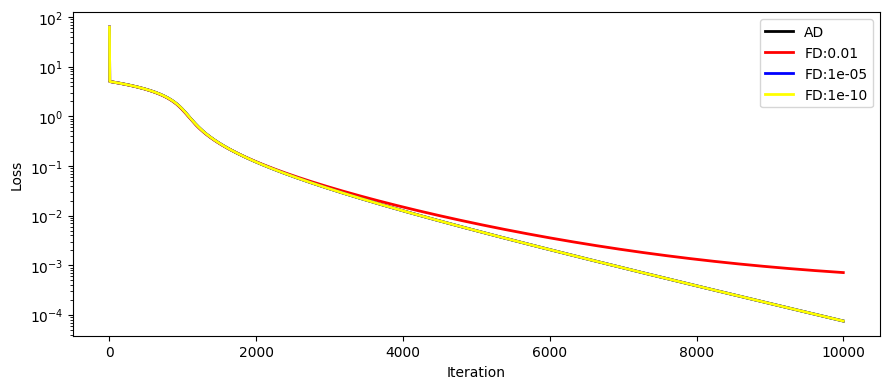

In [9]:
h_values = [1e-2, 1e-5, 1e-10]
plot_color = ["red", "blue", "yellow"]

# For each h, run run_gd with a FD-based gradient function and collect losses
losses_fd = []
for h in h_values:
    loss = run_gd(lambda x: fd_gradient(rosenbrock, x, h), X0_2D)[1]
    losses_fd.append(loss)

# Plot (fill in after implementing above)
plt.figure(figsize=(9, 4))
plt.semilogy(losses_ad, label='AD', color='black', linewidth=2)
for i, loss_fd in enumerate(losses_fd):
    plt.semilogy(loss_fd, label=f"FD:{h_values[i]}", color=plot_color[i], linewidth=2)
plt.legend()
plt.xlabel('Iteration'); plt.ylabel('Loss'); plt.legend(); plt.tight_layout(); plt.show()

# Written answer:
# Q1: Which h suffers from truncation error?  Which from cancellation?
# A: truncation error: 1e-2, h is too large to find smaller value
#    cacellation: 1e-5, 1e-10, h is to small to complete the convergence before the end of iteration

### Tasks 4 & 5 — Efficiency ($d=100$) and JIT speedup

In [10]:
D = 100
x0_d = jnp.ones(D) * 0.5

# Benchmark FD vs AD for a single gradient evaluation at d=100
grad_ad_d = grad(rosenbrock)

_ = grad_ad_d(x0_d).block_until_ready()   # warm-up
N_B = 200
t_fd_d = timeit.timeit(lambda: fd_gradient(rosenbrock, x0_d, 1e-5), number=N_B) / N_B
t_ad_d = timeit.timeit(lambda: grad_ad_d(x0_d).block_until_ready(), number=N_B) / N_B
print(f'd={D}: FD {t_fd_d*1e6:.1f} µs,  AD {t_ad_d*1e6:.1f} µs,  ratio {t_fd_d/t_ad_d:.1f}x')

# JIT the AD update step and benchmark again
@jit
def jit_step(x):
    return x - 1e-3 * grad(rosenbrock)(x)   # one gradient-descent step

_ = jit_step(x0_d).block_until_ready()      # warm-up
t_jit_d = timeit.timeit(lambda: jit_step(x0_d).block_until_ready(), number=N_B) / N_B
print(f'd={D}: AD {t_ad_d*1e6:.1f} μs,  JIT step {t_jit_d*1e6:.1f} μs,  ratio {t_ad_d/t_jit_d:.1f}x')

# Written answer:
# Q: FD needs 2*d=200 evaluations at d=100 vs 2 at d=2. What do your numbers show?
# A: AD is 28 times faster, with git is 794.0 faster

d=100: FD 347893.7 µs,  AD 12251.3 µs,  ratio 28.4x
d=100: AD 12251.3 μs,  JIT step 15.4 μs,  ratio 794.0x


---
## Part 4 — Managing Complex States: PyTrees and Neural Network Regression

### Feedforward neural network

An MLP $f_\theta:\mathbb{R}^{n_{\text{in}}}\to\mathbb{R}^{n_{\text{out}}}$ alternates affine maps and $\tanh$ activations:

$$\mathbf{h}^{(0)}=\mathbf{x}, \qquad \mathbf{h}^{(\ell)}=\tanh\!\left(W^{(\ell)}\mathbf{h}^{(\ell-1)}+\mathbf{b}^{(\ell)}\right), \qquad \hat{y}=W^{(L+1)}\mathbf{h}^{(L)}+\mathbf{b}^{(L+1)}$$

### PyTrees

A **PyTree** is a nested structure of Python dicts/lists/tuples whose leaves are JAX arrays. JAX treats the whole structure as one object: `jax.grad` returns a gradient PyTree of identical shape, and `jax.tree.map(fn, tree)` applies `fn` to every leaf — replacing manual loops over parameters.

We represent $\theta$ as a **list of dicts**, one per layer: `[{'W': ..., 'b': ...}, ...]`.

### Regression target

$g(x)=\sin(2\pi x)+0.5\cos(6\pi x)$ on $[0,1]$. Loss: $\mathcal{L}(\theta)=\frac{1}{M}\sum_i(f_\theta(x_i)-g(x_i))^2$.

### Task 1 — Parameter initialisation

In [59]:
def init_params(layer_sizes, key):
    """
    Input : layer_sizes — list of ints, e.g. [1, 32, 32, 1]
            key         — JAX PRNG key
    Output: list of dicts [{'W': array(n_out, n_in), 'b': array(n_out)}, ...]
            Weights ~ N(0,1)*sqrt(2/n_in), biases = 0.
            Split the key once per layer for independent initialisations.
    """
    params = []
    for n_in, n_out in zip(layer_sizes[:-1], layer_sizes[1:]):
        key, subkey = random.split(key)
        W = random.normal(subkey, (n_out, n_in)) * jnp.sqrt(2.0 / n_in)
        b = jnp.zeros(n_out)
        params.append({'W': W, 'b': b})
    return params

In [12]:
LAYERS = [1, 32, 32, 1]
params = init_params(LAYERS, random.key(0))

assert len(params) == len(LAYERS) - 1
for i, (p, (n_in, n_out)) in enumerate(zip(params, zip(LAYERS, LAYERS[1:]))):
    assert p['W'].shape == (n_out, n_in),  f'Layer {i} W shape wrong'
    assert p['b'].shape == (n_out,),        f'Layer {i} b shape wrong'
print('init_params: OK')
print('Leaves:', [leaf.shape for leaf in jax.tree.leaves(params)])

init_params: OK
Leaves: [(32, 1), (32,), (32, 32), (32,), (1, 32), (1,)]


### Task 2 — Forward pass

Apply $\tanh$ after every hidden layer; no activation on the output layer. Your implementation must work for any depth — do not hard-code the number of layers.

In [13]:
def forward(params, x):
    """
    Input : params — list of dicts from init_params
            x      — scalar or jnp.array shape (n_in,)
    Output: scalar — network output
    """
    h = jnp.atleast_1d(x)                            # ensure array shape (n_in,)

    for layer in params[:-1]:                         # hidden layers with tanh
        h = jnp.tanh(layer['W'] @ h + layer['b'])    # h^(l) = tanh(W h + b)

    W, b = params[-1]['W'], params[-1]['b']

    return (W @ h + b).squeeze()

In [14]:
y = forward(params, jnp.array([0.5]))
assert y.shape == (), f'Expected scalar output, got shape {y.shape}'

# Test that depth works: try a deeper network
p_deep = init_params([1, 16, 16, 16, 1], random.key(1))
y_deep = forward(p_deep, jnp.array([0.3]))
assert y_deep.shape == ()
print('forward: OK')

forward: OK


### Task 3 — MSE loss and its gradient

The gradient of `mse_loss` w.r.t. `params` is a PyTree of the **same structure** as `params` — `jax.grad` handles this automatically.

In [15]:
def target_fn(x):
    return jnp.sin(2 * jnp.pi * x) + 0.5 * jnp.cos(6 * jnp.pi * x)

def mse_loss(params, X, Y):
    """
    Input : params — PyTree
            X, Y   — jnp.arrays shape (M,), training inputs and targets
    Output: scalar MSE
    Use vmap to evaluate forward over all inputs simultaneously.
    """
    preds = vmap(forward, in_axes=(None, 0))(params, X)   # (M,)
    return jnp.mean((preds - Y) ** 2)

# Define grad_loss: gradient of mse_loss w.r.t. params (argnums=0)
grad_loss = jax.grad(mse_loss, argnums=0)

In [16]:
Xt = jnp.linspace(0, 1, 20)
Yt = target_fn(Xt)
l0 = mse_loss(params, Xt, Yt)
g0 = grad_loss(params, Xt, Yt)
print(f'Initial loss: {float(l0):.4f}')
assert jax.tree.structure(g0) == jax.tree.structure(params), 'Gradient structure mismatch'

Initial loss: 0.6423


### Task 4 — Parameter update with `jax.tree.map`

Apply the gradient step $\theta \leftarrow \theta - \alpha\nabla_\theta\mathcal{L}$ to **all** leaves simultaneously with a **single** `jax.tree.map` call. Do not write a loop over layers.

In [18]:
def update(params, X, Y, lr=1e-3):
    """
    Input : params — PyTree
            X, Y   — training arrays
            lr     — learning rate
    Output: (new_params, loss_val)
            new_params has the same PyTree structure as params.
    """
    loss_val = mse_loss(params, X, Y)
    grads = grad_loss(params, X, Y)

    # single jax.tree.map call over all leaves simultaneously
    new_params = jax.tree.map(lambda p, g: p - lr * g, params, grads)

    return new_params, loss_val

In [19]:
params1, loss0 = update(params, Xt, Yt)
loss1 = mse_loss(params1, Xt, Yt)
print(f'Loss before: {float(loss0):.6f},  after: {float(loss1):.6f}')
assert float(loss1) < float(loss0), 'Loss did not decrease after one update'

Loss before: 0.642280,  after: 0.639115


### Task 5 — Training loop

In [20]:
# Setup (given)
X_train = jnp.linspace(0.0, 1.0, 200)
Y_train = target_fn(X_train)
params  = init_params(LAYERS, random.key(1))   # fresh initialisation

In [60]:
# Train for 5000 iterations; record loss every 100 steps in loss_history
loss_history = []
for i in range(5000):
    params, loss_val = update(params, X_train, Y_train, lr=3*1e-2)
    if i % 100 == 0:
        loss_history.append(float(loss_val))

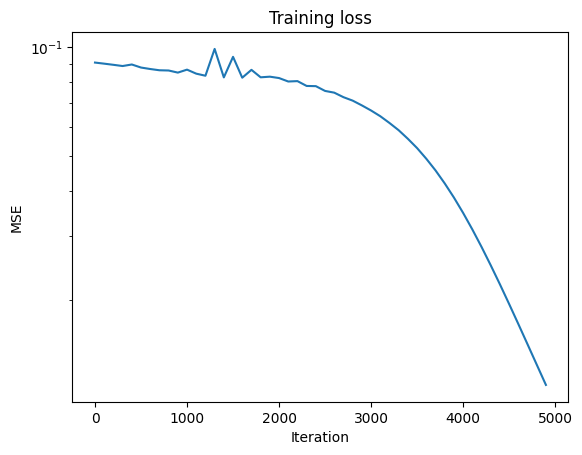

In [61]:
assert len(loss_history) == 50
assert loss_history[-1] < loss_history[0], 'Loss did not converge'
plt.semilogy(range(0, 5000, 100), loss_history)
plt.xlabel('Iteration'); plt.ylabel('MSE'); plt.title('Training loss'); plt.show()

### Tasks 6 & 7 — Verification plot and JIT speedup

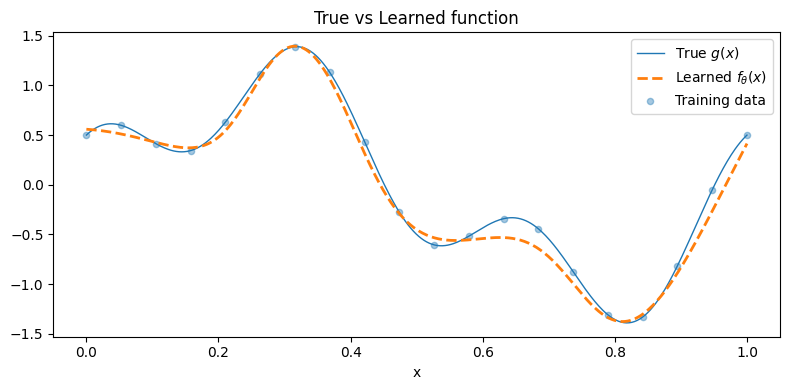

No-JIT: 22.96 ms
JIT   : 0.10 ms
Speedup: 227.4x
Loss match: True
True
True
True
True
True
True


[{'W': None, 'b': None}, {'W': None, 'b': None}, {'W': None, 'b': None}]

In [62]:
# Task 6: plot true g(x) vs learned f_theta(x) on 500 test points in [0,1]
X_test = jnp.linspace(0, 1, 500)
Y_true = vmap(target_fn)(X_test)
Y_pred = vmap(forward, in_axes=(None, 0))(params, X_test)

plt.figure(figsize=(8, 4))
plt.plot(X_test, Y_true, label='True $g(x)$', linewidth=1)
plt.plot(X_test, Y_pred, '--', label='Learned $f_\\theta(x)$', linewidth=2)
plt.scatter(Xt, Yt, s=20, alpha=0.4, label='Training data')
plt.legend(); plt.xlabel('x'); plt.title('True vs Learned function')
plt.tight_layout(); plt.show()

# Task 7: JIT the update step, benchmark vs non-JIT, verify identical results
update_jit = jax.jit(update)
_ = update_jit(params, Xt, Yt)

N_B = 100
t_nojit = timeit.timeit(
    lambda: jax.block_until_ready(update(params, Xt, Yt)),   number=N_B) / N_B
t_jit   = timeit.timeit(
    lambda: jax.block_until_ready(update_jit(params, Xt, Yt)), number=N_B) / N_B

print(f'No-JIT: {t_nojit*1e3:.2f} ms')
print(f'JIT   : {t_jit*1e3:.2f} ms')
print(f'Speedup: {t_nojit/t_jit:.1f}x')

# verify identical results
p1, l1 = update(params, Xt, Yt)
p2, l2 = update_jit(params, Xt, Yt)
print(f'Loss match: {jnp.allclose(l1, l2)}')
jax.tree.map(lambda a, b: print(jnp.allclose(a, b)), p1, p2)

In [63]:
# Minimal check: learned curve should be close to target
X_test = jnp.linspace(0.0, 1.0, 500)
Y_pred = vmap(lambda x: forward(params, jnp.array([x])))(X_test)
Y_true = target_fn(X_test)
test_mse = float(jnp.mean((Y_pred - Y_true)**2))
print(f'Test MSE: {test_mse:.4f}')
assert test_mse < 0.05, 'Network did not converge well enough'

Test MSE: 0.0103


---
## Part 5 — Capstone: Physics-Informed Neural Network (PINN)

### Solving an ODE with a neural network

In Part 4 you fit data. A **PINN** instead trains the network to satisfy a *differential equation* — no $(t, u(t))$ dataset is needed. We parameterise the solution as $u_\theta(t)$ (the network output) and minimise a loss that penalises violations of the equation and initial conditions.

Because JAX differentiates through the network, $u'_\theta(t)$ is computed exactly by applying `jax.grad` with respect to the *input* $t$, not the parameters.

### Math — simple harmonic oscillator

$$u''(t)+\omega^2 u(t)=0,\quad t\in[0,T],\qquad u(0)=1,\;u'(0)=0$$

Exact solution: $u(t)=\cos(\omega t)$.

**PINN loss:**
$$\mathcal{L}(\theta)=\frac{1}{N_c}\sum_{i=1}^{N_c}\left[u''_\theta(t_i)+\omega^2 u_\theta(t_i)\right]^2 +\lambda\left[(u_\theta(0)-1)^2+(u'_\theta(0))^2\right]$$

### Architecture requirements

Your solution **must** use:
1. `init_params` / `forward` / `jax.tree.map` from Part 4
2. `jax.grad` twice w.r.t. $t$ to obtain $u''_\theta$
3. `jax.vmap` over collocation points
4. `jax.jit` around the full update step
5. `jax.lax.fori_loop` for the training loop

In [155]:
# Setup (given)
OMEGA   = 1.0
T_MAX   = 2 * jnp.pi
N_COLL  = 100
LAM     = 10.0      # IC penalty weight
LR_PINN = 5e-4
N_PINN  = 20_000

t_coll      = jnp.linspace(0.0, T_MAX, N_COLL)
pinn_params = init_params([1, 32, 32, 32, 1], random.key(99))

def exact(t):
    return jnp.cos(OMEGA * t)

### Tasks 1 & 2 — Derivatives and physics loss

**Task 1.** Implement `u_theta`, `u_prime`, `u_double_prime`, and `ode_residual`.
- Differentiate w.r.t. `t`, not `params`.
- `u_theta` and `u_prime` are needed inside `u_double_prime`; `u_prime` is also needed for the IC penalty.

**Task 2.** Implement `pinn_loss` using `vmap` over collocation points. No Python loop over `t_coll`.

In [156]:
def u_theta(params, t):
    """
    Input : params — PyTree;  t — scalar
    Output: scalar network output u_theta(t)
    """
    return forward(params, jnp.atleast_1d(t))

def u_prime(params, t):
    """
    Input : params — PyTree;  t — scalar
    Output: scalar du_theta/dt at t  (differentiate w.r.t. t only)
    """
    return grad(u_theta, argnums=1)(params, t)

def u_double_prime(params, t):
    """
    Input : params — PyTree;  t — scalar
    Output: scalar d²u_theta/dt² at t
    """
    return grad(
        lambda t_: grad(u_theta, argnums=1)(params, t_)
    )(t)

def ode_residual(params, t):
    """
    Input : params — PyTree;  t — scalar
    Output: scalar  u''_theta(t) + omega^2 * u_theta(t)
    """
    return u_double_prime(params, t) + OMEGA**2 * u_theta(params, t)

def pinn_loss(params, t_colloc):
    """
    Input : params    — PyTree
            t_colloc  — jnp.array shape (N_c,)
    Output: scalar total PINN loss (ODE residual + IC penalty)
    Must use vmap over t_colloc; no Python loop.
    """
    # ODE residual term:
    residuals = vmap(ode_residual, in_axes=(None, 0))(params, t_colloc)  # (N_c,)
    ode_loss  = jnp.mean(residuals ** 2)

    # Initial condition penalty: λ[(u(0)-1)² + (u'(0))²]
    ic_u  = u_theta(params, 0.0) - 1.0
    ic_du = u_prime(params, 0.0)
    ic_loss = LAM * (ic_u**2 + ic_du**2)

    return (ode_loss + ic_loss)/N_COLL

In [157]:
# Verify derivatives: check callability and that all outputs are scalars
t_zero = jnp.float64(0.0)
for name, fn in [('u_theta', u_theta), ('u_prime', u_prime),
                 ('u_double_prime', u_double_prime), ('ode_residual', ode_residual)]:
    val = fn(pinn_params, t_zero)
    assert val.shape == (), f'{name} must return a scalar, got shape {val.shape}'
    print(f'{name:16s}: {float(val):.4f}')

loss_val = pinn_loss(pinn_params, t_coll)
assert loss_val.shape == (), 'pinn_loss must return a scalar'
print(f'{"pinn_loss":16s}: {float(loss_val):.4f}')
print('All shapes: OK')

u_theta         : 0.0000
u_prime         : 2.8179
u_double_prime  : 0.0000
ode_residual    : 0.0000
pinn_loss       : 0.9394
All shapes: OK


### Tasks 3–5 — JIT update step and `fori_loop` training

In [158]:
def pinn_update(params):
    """
    Input : params   — PyTree
    Output: updated params after one gradient step on pinn_loss
    """
    grads    = jax.grad(pinn_loss, argnums=0)(params, t_coll)
    new_params = jax.tree.map(lambda p, g: p - LR_PINN * g, params, grads)
    return new_params


# Task 3b: training loop via lax.fori_loop

def body_fun(i, carry):
    params = carry
    params = pinn_update(params)
    return params

pinn_params_trained = jax.lax.fori_loop(0, N_PINN, body_fun, pinn_params)

In [159]:
# The cell above includes JIT compilation (first call).
# Re-run here to measure pure execution time (post-JIT warm-up).
t_start = time.time()
pinn_params_trained = lax.fori_loop(0, N_PINN, lambda i, p: pinn_update(p), pinn_params)
jax.block_until_ready(pinn_params_trained)
print(f'Wall-clock (excl. JIT warm-up): {time.time() - t_start:.2f} s')
print(f'Final PINN loss: {float(pinn_loss(pinn_params_trained, t_coll)):.2e}')

Wall-clock (excl. JIT warm-up): 29.81 s
Final PINN loss: 1.34e-03


### Tasks 4 & 5 — Plot and MSE report

In [160]:
# Compute learned solution on 500 test points and plot vs exact solution
t_eval    = jnp.linspace(0., T_MAX, 500)
u_learned = vmap(u_theta, in_axes=(None, 0))(pinn_params_trained, t_eval)

In [161]:
t_eval  = jnp.linspace(0.0, T_MAX, 500)
u_exact = exact(t_eval)
assert u_learned.shape == (500,), f'u_learned must have shape (500,), got {u_learned.shape}'
mse = float(jnp.mean((u_learned - u_exact)**2))
print(f'Test MSE (500 points): {mse:.2e}')
assert mse < 0.1, f'MSE {mse:.2e} too high — check your training loop'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t_eval, u_exact,   label='Exact $\\cos(\\omega t)$', lw=2)
axes[0].plot(t_eval, u_learned, label='PINN $u_\\theta(t)$', lw=2, ls='--')
axes[0].set(xlabel='t', ylabel='u(t)', title='PINN vs. exact')
axes[0].legend()
axes[1].semilogy(t_eval, np.abs(np.array(u_learned) - np.array(u_exact)))
axes[1].set(xlabel='t', ylabel='|error|', title='Pointwise error')
plt.tight_layout(); plt.show()

Test MSE (500 points): 4.12e-01


AssertionError: MSE 4.12e-01 too high — check your training loop

---
## Extra Credit — Speed Competition

A hidden test set of **1 000 collocation points** on $[0, 2\pi]$ will be used. The team whose implementation reaches **MSE $< 10^{-4}$** in the shortest wall-clock time (JIT warm-up excluded) wins.

Questions worth exploring: How does $N_c$ affect compile time vs. per-step cost? Does `lax.fori_loop` reduce warm-up vs. a Python loop over `@jit` steps? Can a better learning-rate schedule reduce the required number of iterations? Does wider/deeper architecture help?

---
## Submission Checklist

| Part | Required outputs |
|------|------------------|
| 1 | `bisection_np`, `bisection_jax`; error explanation; benchmark table |
| 2 | `sim_path`; key-reuse explanation; vmap run; benchmark; relative error vs. analytical |
| 3 | `fd_gradient`, `run_gd`; convergence plot with written interpretation; $d=100$ efficiency table |
| 4 | `init_params`, `forward`, `mse_loss`, `update`; training curve; approximation plot; JIT speedup |
| 5 | Full PINN (all 5 requirements); solution + error plots; final MSE |